# Road Damage Intelligence (RDD2020) — YOLO26n Benchmark & Diagnostics
### End-to-End Training, Evaluation, and Comparative Analysis on Kaggle GPU

This notebook implements a full deep learning workflow for automated road damage detection on the **RDD2020** benchmark dataset using **YOLO26n** (trained at 768px resolution) and provides side-by-side comparative analysis against a baseline **YOLO11n** model.

---

### Key Objectives & Experiment Configuration
* **Architecture**: Ultralytics YOLO26n (`yolo26n.pt`) with anchor-free detection head
* **Input Resolution**: `768 × 768` for fine-grained pavement distress detection
* **Training Schedule**: 50 Epochs, Early Stopping Patience = 10, AdamW / Auto Optimizer
* **Hardware Optimization**: FP16 Automatic Mixed Precision (`amp=True`) on GPU (Tesla T4 / P100)
* **Dataset**: RDD2020 multi-country road pavement dataset (80% Train / 20% Validation, seed `42`)

---

###  Target Damage Categories
| Class ID | Code | Category | Visual Symptoms & Impact |
| :---: | :---: | :--- | :--- |
| **0** | **D00** | Longitudinal Crack | Cracks running parallel to traffic direction along wheelpaths or construction joints |
| **1** | **D10** | Transverse Crack | Cracks running perpendicular to the roadway centerline, often caused by thermal cycles |
| **2** | **D20** | Alligator Crack | Interconnected polygonal cracking patterns indicating structural fatigue |
| **3** | **D40** | Pothole / Rutting / Bump | Bowl-shaped road surface depressions and localized structural failures |

---

###  Workflow Structure
1. **Environment & GPU Setup**: CUDA device capability check and library initialization.
2. **Dataset Discovery & Path Configuration**: Safe discovery of RDD2020 YOLO structure.
3. **Data Inspection & Ground Truth Visual Audit**: Visualizing labels and class distributions.
4. **YOLO26n Training & Artifact Staging**: 50-epoch training run with model checkpoint persistence.
5. **Training Dynamics & Convergence Diagnostics**: Analysis of box loss, class loss, mAP, and precision/recall trajectories.
6. **Strict Checkpoint Validation**: Quantitative benchmark of `best.pt` on the validation set.
7. **Qualitative Detection Visualizations**: Ground Truth vs. YOLO26n prediction overlays.
8. **Summary Performance Report**: Consolidated metrics table across all damage classes.
9. **Error Analysis (False Positives & False Negatives)**: Systematic diagnosis of detector confusion modes.
10. **Comparative Prototype**: Side-by-side qualitative comparison between YOLO11n (640px) and YOLO26n (768px).

##  1. Environment Setup & Hardware Verification
We start by verifying GPU availability, CUDA drivers, and importing the required deep learning and computer vision libraries.

In [1]:

# Check available GPU in Kaggle
!nvidia-smi

# Install required packages (Ultralytics and dependencies)
!pip install -q ultralytics opencv-python matplotlib seaborn pyyaml tqdm

import os
import sys
import shutil
import random
import yaml
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
from ultralytics import YOLO



Sun Oct  4 17:12:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
from pathlib import Path

for p in Path("/kaggle/working").glob("**/data.yaml"):
    print(p)

/kaggle/working/data.yaml
/kaggle/working/data/yolo/data.yaml


## 2. Kaggle Workspace & Dataset Discovery
In Kaggle environments, `/kaggle/input` provides read-only dataset access while `/kaggle/working` acts as the persistent workspace for model checkpoints and logs.

The discovery logic automatically detects the active `data.yaml` configuration and validates paths to training and validation splits.

In [17]:
from pathlib import Path
import yaml

IS_KAGGLE = Path("/kaggle").exists()

if IS_KAGGLE:
    WORKSPACE_DIR = Path("/kaggle/working")
    INPUT_ROOT = Path("/kaggle/input")
else:
    WORKSPACE_DIR = Path(".").resolve()
    INPUT_ROOT = WORKSPACE_DIR / "data"

# IMPORTANT:
# The dataset is READ-ONLY.
# Only YOLO26n experiment outputs are written to /kaggle/working.
OUTPUT_DIR = WORKSPACE_DIR / "outputs" / "training" / "yolo26n_rdd2020_768"


def find_rdd2020_dataset():
    candidates = list(INPUT_ROOT.rglob("data.yaml"))
    if not candidates:
        local_candidate = WORKSPACE_DIR / "data" / "yolo" / "data.yaml"
        if local_candidate.exists():
            candidates.append(local_candidate)

    for yaml_path in candidates:
        try:
            with open(yaml_path, "r") as f:
                data = yaml.safe_load(f)

            names = data.get("names", {})
            if isinstance(names, dict):
                names = {int(k): v for k, v in names.items()}

            expected_names = {
                0: "D00",
                1: "D10",
                2: "D20",
                3: "D40",
            }

            if names != expected_names:
                continue

            dataset_root = yaml_path.parent

            train_images = dataset_root / "train" / "images"
            val_images = dataset_root / "val" / "images"

            if train_images.exists() and val_images.exists():
                print(f"Found existing RDD2020 YOLO dataset:")
                print(f"  {yaml_path}")
                print(f"  Train images: {train_images}")
                print(f"  Val images:   {val_images}")

                return yaml_path

        except Exception:
            continue

    return None


DATA_YAML_PATH = find_rdd2020_dataset()

if DATA_YAML_PATH is None:
    raise FileNotFoundError(
        "\nRDD2020 YOLO dataset not found.\n\n"
        "Attach the existing RDD2020 YOLO dataset to this Kaggle notebook "
        "as an Input Dataset.\n"
        "The dataset must contain data.yaml, train/images, train/labels, "
        "val/images and val/labels.\n"
    )
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("\nYOLO26n experiment configuration")
print("--------------------------------")
print(f"Dataset : {DATA_YAML_PATH}")
print(f"Output  : {OUTPUT_DIR}")

Found existing RDD2020 YOLO dataset:
  /kaggle/working/data/yolo/data.yaml
  Train images: /kaggle/working/data/yolo/train/images
  Val images:   /kaggle/working/data/yolo/val/images

YOLO26n experiment configuration
--------------------------------
Dataset : /kaggle/working/data/yolo/data.yaml
Output  : /kaggle/working/outputs/training/yolo26n_rdd2020_768


In [ ]:
# ==============================================================================
# 3. Dataset Audit & Annotation Visualizer
# ==============================================================================

CLASS_COLORS_RGB = {
    0: (230, 25, 75),    # Red - D00 Longitudinal
    1: (255, 225, 25),   # Yellow - D10 Transverse
    2: (0, 130, 200),    # Blue - D20 Alligator
    3: (60, 180, 75)     # Green - D40 Pothole/Rutting
}


def read_yolo_labels(label_path: Path) -> list:
    """Reads normalized YOLO label file and returns list of (cls_id, x, y, w, h)."""
    annotations = []
    if label_path.exists():
        with open(label_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    annotations.append((
                        int(parts[0]),
                        float(parts[1]),
                        float(parts[2]),
                        float(parts[3]),
                        float(parts[4]),
                    ))
    return annotations


def draw_yolo_annotations_rgb(image_rgb: np.ndarray, annotations: list) -> np.ndarray:
    """Draws ground truth bounding boxes and class tags on an RGB image."""
    img = image_rgb.copy()
    h, w, _ = img.shape
    min_dim = float(min(w, h))

    if len(annotations) == 0:
        label_text = "Background (No damage)"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = max(0.5, min_dim / 1200.0)
        thickness = max(1, int(min_dim / 600.0))
        (tw, th), bl = cv2.getTextSize(label_text, font, font_scale, thickness)
        cv2.rectangle(img, (10, 10), (20 + tw, 20 + th + bl), (50, 50, 50), -1)
        cv2.putText(img, label_text, (15, 15 + th), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)
        return img

    for cls_id, x_center, y_center, box_w, box_h in annotations:
        cls_name = CLASS_NAMES.get(cls_id, f"Class {cls_id}")
        color = CLASS_COLORS_RGB.get(cls_id, (0, 255, 0))

        xmin = max(0, min(w - 1, int((x_center - box_w / 2.0) * w)))
        ymin = max(0, min(h - 1, int((y_center - box_h / 2.0) * h)))
        xmax = max(0, min(w - 1, int((x_center + box_w / 2.0) * w)))
        ymax = max(0, min(h - 1, int((y_center + box_h / 2.0) * h)))

        box_thickness = max(2, int(min_dim / 350.0))
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, box_thickness)

        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = max(0.5, min_dim / 1000.0)
        text_thickness = max(1, int(min_dim / 500.0))
        (tw, th), bl = cv2.getTextSize(cls_name, font, font_scale, text_thickness)

        tag_ymin = max(0, ymin - th - 6)
        tag_ymax = ymin
        tag_xmax = min(w, xmin + tw + 6)

        cv2.rectangle(img, (xmin, tag_ymin), (tag_xmax, tag_ymax), color, -1)
        cv2.putText(img, cls_name, (xmin + 3, tag_ymax - 3), font, font_scale, (255, 255, 255), text_thickness, cv2.LINE_AA)

    return img


def audit_and_preview_dataset(yaml_path: Path, num_preview: int = 8):
    """Audits dataset split counts and displays preview grid of ground truth images."""
    with open(yaml_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    base = Path(cfg.get("path", yaml_path.parent))
    train_dir = Path(cfg["train"]) if Path(cfg["train"]).is_absolute() else base / cfg["train"]
    val_dir = Path(cfg["val"]) if Path(cfg["val"]).is_absolute() else base / cfg["val"]

    train_lbl_dir = train_dir.parent / "labels" if train_dir.parent.name != "images" else train_dir.parent.parent / "labels"
    val_lbl_dir = val_dir.parent / "labels" if val_dir.parent.name != "images" else val_dir.parent.parent / "labels"
    if not train_lbl_dir.exists():
        train_lbl_dir = train_dir.parent / "train" / "labels"
    if not val_lbl_dir.exists():
        val_lbl_dir = val_dir.parent / "val" / "labels"

    train_imgs = sorted(list(train_dir.glob("*.jpg")) + list(train_dir.glob("*.png")))
    val_imgs = sorted(list(val_dir.glob("*.jpg")) + list(val_dir.glob("*.png")))

    print("=" * 60)
    print("DATASET AUDIT REPORT")
    print(f"Train Images Directory: {train_dir} ({len(train_imgs):,} images)")
    print(f"Val Images Directory  : {val_dir} ({len(val_imgs):,} images)")
    print(f"Classes               : {cfg.get('names', CLASS_NAMES)}")
    print("=" * 60)

    # Preview annotated samples
    annotated_samples = []
    for img_p in train_imgs:
        lbl_p = train_lbl_dir / f"{img_p.stem}.txt"
        ann = read_yolo_labels(lbl_p)
        if len(ann) > 0:
            annotated_samples.append((img_p, ann))
        if len(annotated_samples) >= num_preview:
            break

    if annotated_samples:
        cols = 4
        rows = int(np.ceil(len(annotated_samples) / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(18, 4.5 * rows))
        axes = np.array(axes).flatten()

        for idx, (img_p, ann) in enumerate(annotated_samples):
            bgr = cv2.imread(str(img_p))
            if bgr is None:
                continue
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            vis = draw_yolo_annotations_rgb(rgb, ann)
            axes[idx].imshow(vis)
            axes[idx].set_title(f"{img_p.name}\n({len(ann)} annotations)", fontsize=9)
            axes[idx].axis("off")

        for idx in range(len(annotated_samples), len(axes)):
            axes[idx].axis("off")

        plt.suptitle("RDD2020 Ground Truth Samples", fontsize=14, fontweight="bold", y=0.98)
        plt.tight_layout()
        plt.show()


audit_and_preview_dataset(DATA_YAML_PATH, num_preview=8)


## 3. YOLO26n Model Training & Checkpoint Persistence
We initialize the YOLO26n backbone and launch training at `768 × 768` resolution with Automatic Mixed Precision (`amp=True`).

Key checkpoint artifacts (`best.pt`, `last.pt`, `results.csv`, and confusion matrices) are automatically staged in the top-level workspace directory for direct persistence and export.

In [18]:
# 3. YOLO26n Training Execution & Artifact Persistence

device = 0 if torch.cuda.is_available() else "cpu"
print("=" * 60)
print(f"Starting YOLO26n Baseline Training on device: {device}")
print(f"Data YAML Config : {DATA_YAML_PATH}")
print(f"Target Output Dir: {OUTPUT_DIR}")
print("=" * 60)

# Initialize YOLO26n model
model = YOLO("yolo26n.pt")

# Train YOLO26n model
training_results = model.train(
    data=str(DATA_YAML_PATH),
    epochs=50,
    imgsz=768,
    batch=16,
    device=device,
    workers=2,
    amp=True,
    optimizer="auto",
    patience=10,
    cache=False,
    project=str(OUTPUT_DIR.parent),
    name=OUTPUT_DIR.name,
    exist_ok=True,
    plots=True,
)

# Identify trained weights
trained_best_pt = OUTPUT_DIR / "weights" / "best.pt"
trained_last_pt = OUTPUT_DIR / "weights" / "last.pt"

print("\n" + "=" * 60)
print("TRAINING FINISHED")
print(f"Exact best checkpoint path: {trained_best_pt}")
print(f"Exact last checkpoint path: {trained_last_pt}")
print("=" * 60)

# ==============================================================================
# Top-Level Artifact Persistence (Guarantees easy download from Kaggle output)
persisted_artifacts = []

# 1. Stage best.pt and last.pt in /kaggle/working/ root
if trained_best_pt.exists():
    staged_best = WORKSPACE_DIR / "yolo26n_rdd2020_640_best.pt"
    staged_best_short = WORKSPACE_DIR / "best.pt"
    shutil.copy2(trained_best_pt, staged_best)
    shutil.copy2(trained_best_pt, staged_best_short)
    persisted_artifacts.append(staged_best)
    persisted_artifacts.append(staged_best_short)

if trained_last_pt.exists():
    staged_last = WORKSPACE_DIR / "yolo26n_rdd2020_640_last.pt"
    shutil.copy2(trained_last_pt, staged_last)
    persisted_artifacts.append(staged_last)

# 2. Stage results.csv and confusion matrix
results_csv_path = OUTPUT_DIR / "results.csv"
if results_csv_path.exists():
    staged_csv = WORKSPACE_DIR / "results.csv"
    shutil.copy2(results_csv_path, staged_csv)
    persisted_artifacts.append(staged_csv)

cm_path = OUTPUT_DIR / "confusion_matrix.png"
if cm_path.exists():
    staged_cm = WORKSPACE_DIR / "confusion_matrix.png"
    shutil.copy2(cm_path, staged_cm)
    persisted_artifacts.append(staged_cm)

print("\nPersisted Kaggle Output Artifacts:")
for art in persisted_artifacts:
    size_mb = art.stat().st_size / (1024**2)
    print(f"  [✓] {art.name:<32} ({size_mb:6.2f} MB) -> {art}")
print("=" * 60)


Starting YOLO26n Baseline Training on device: 0
Data YAML Config : /kaggle/working/data/yolo/data.yaml
Target Output Dir: /kaggle/working/outputs/training/yolo26n_rdd2020_768
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data/yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.0

## 4. Training Curves & Convergence Diagnostics
Here we visualize the progression of box loss, classification loss, precision, recall, and mean Average Precision (`mAP@50` & `mAP@50-95`) across the full training cycle.

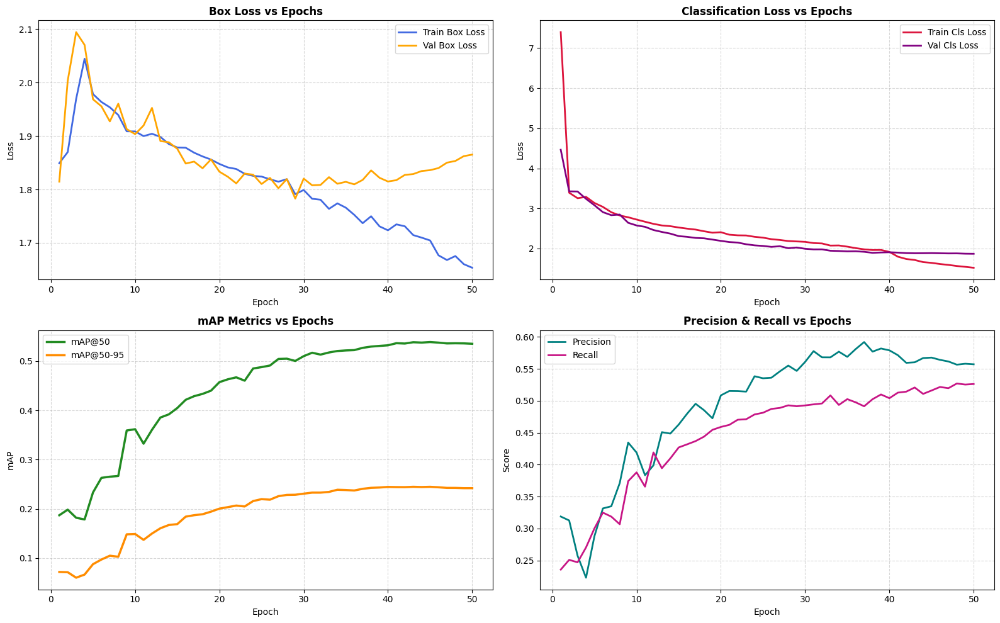

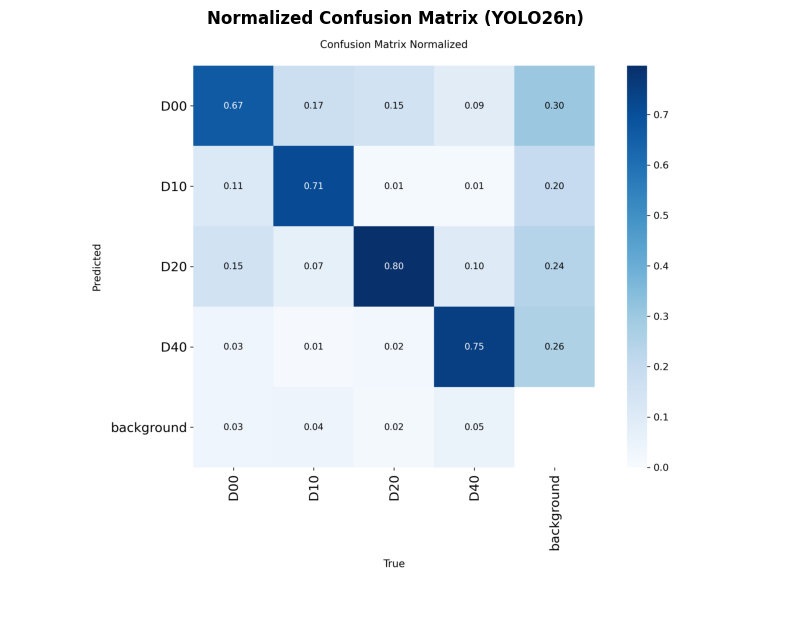

In [20]:
# 4. Training Curves & Loss Diagnostics

results_csv = OUTPUT_DIR / "results.csv"

if results_csv.exists():
    df_results = pd.read_csv(results_csv)
    df_results.columns = [c.strip() for c in df_results.columns]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Box Loss
    if "train/box_loss" in df_results.columns:
        axes[0, 0].plot(df_results["epoch"], df_results["train/box_loss"], label="Train Box Loss", color="royalblue", lw=2)
    if "val/box_loss" in df_results.columns:
        axes[0, 0].plot(df_results["epoch"], df_results["val/box_loss"], label="Val Box Loss", color="orange", lw=2)
    axes[0, 0].set_title("Box Loss vs Epochs", fontsize=12, fontweight="bold")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle="--", alpha=0.5)

    # 2. Classification Loss
    if "train/cls_loss" in df_results.columns:
        axes[0, 1].plot(df_results["epoch"], df_results["train/cls_loss"], label="Train Cls Loss", color="crimson", lw=2)
    if "val/cls_loss" in df_results.columns:
        axes[0, 1].plot(df_results["epoch"], df_results["val/cls_loss"], label="Val Cls Loss", color="purple", lw=2)
    axes[0, 1].set_title("Classification Loss vs Epochs", fontsize=12, fontweight="bold")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Loss")
    axes[0, 1].legend()
    axes[0, 1].grid(True, linestyle="--", alpha=0.5)

    # 3. mAP@50 and mAP@50-95
    map50_col = "metrics/mAP50(B)" if "metrics/mAP50(B)" in df_results.columns else "metrics/mAP_0.5"
    map5095_col = "metrics/mAP50-95(B)" if "metrics/mAP50-95(B)" in df_results.columns else "metrics/mAP_0.5:0.95"
    if map50_col in df_results.columns:
        axes[1, 0].plot(df_results["epoch"], df_results[map50_col], label="mAP@50", color="forestgreen", lw=2.5)
    if map5095_col in df_results.columns:
        axes[1, 0].plot(df_results["epoch"], df_results[map5095_col], label="mAP@50-95", color="darkorange", lw=2.5)
    axes[1, 0].set_title("mAP Metrics vs Epochs", fontsize=12, fontweight="bold")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("mAP")
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle="--", alpha=0.5)

    # 4. Precision & Recall
    p_col = "metrics/precision(B)" if "metrics/precision(B)" in df_results.columns else "metrics/precision"
    r_col = "metrics/recall(B)" if "metrics/recall(B)" in df_results.columns else "metrics/recall"
    if p_col in df_results.columns:
        axes[1, 1].plot(df_results["epoch"], df_results[p_col], label="Precision", color="teal", lw=2)
    if r_col in df_results.columns:
        axes[1, 1].plot(df_results["epoch"], df_results[r_col], label="Recall", color="mediumvioletred", lw=2)
    axes[1, 1].set_title("Precision & Recall vs Epochs", fontsize=12, fontweight="bold")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Score")
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(WORKSPACE_DIR / "training_curves.png", dpi=150)
    plt.show()

# Display confusion matrix if generated
cm_img_path = OUTPUT_DIR / "confusion_matrix_normalized.png"
if not cm_img_path.exists():
    cm_img_path = OUTPUT_DIR / "confusion_matrix.png"

if cm_img_path.exists():
    cm_bgr = cv2.imread(str(cm_img_path))
    if cm_bgr is not None:
        plt.figure(figsize=(8, 7))
        plt.imshow(cv2.cvtColor(cm_bgr, cv2.COLOR_BGR2RGB))
        plt.title("Normalized Confusion Matrix (YOLO26n)", fontsize=12, fontweight="bold")
        plt.axis("off")
        plt.tight_layout()
        plt.show()


## 🎯 6. Quantitative Evaluation on Validation Set
We load the verified `best.pt` checkpoint to compute official validation metrics across all 4 damage classes. A strict safeguard prevents fallback to uninitialized weights.

In [21]:
# 5. Explicit Checkpoint Evaluation & Per-Class Metrics

best_checkpoint_path = OUTPUT_DIR / "weights" / "best.pt"

if not best_checkpoint_path.exists():
    fallback_best = WORKSPACE_DIR / "yolo26n_rdd2020_768_best.pt"
    if fallback_best.exists():
        best_checkpoint_path = fallback_best
    else:
        raise FileNotFoundError(
            f"CRITICAL ERROR: Trained checkpoint 'best.pt' not found at {best_checkpoint_path}. "
            "Silently evaluating the untrained base model 'yolo26n.pt' is STRICTLY FORBIDDEN. "
            "Please check training logs to verify why checkpoint was not created."
        )

print(f"[✓] Loading verified trained checkpoint from: {best_checkpoint_path}")
eval_model = YOLO(str(best_checkpoint_path))

val_metrics = eval_model.val(
    data=str(DATA_YAML_PATH),
    split="val",
    imgsz=640,
    batch=16,
    device=device,
    plots=True,
)

# Extract overall metrics
overall_mp = float(val_metrics.box.mp)
overall_mr = float(val_metrics.box.mr)
overall_map50 = float(val_metrics.box.map50)
overall_map5095 = float(val_metrics.box.map)

# Extract per-class metrics safely
maps_arr = getattr(val_metrics.box, "maps", None)
ap50_arr = getattr(val_metrics.box, "ap50", None)
p_arr = getattr(val_metrics.box, "p", None)
r_arr = getattr(val_metrics.box, "r", None)

per_class_results = {}
for cls_id, cls_name in CLASS_NAMES.items():
    cls_map5095 = float(maps_arr[cls_id]) if (maps_arr is not None and cls_id < len(maps_arr)) else 0.0
    cls_ap50 = float(ap50_arr[cls_id]) if (ap50_arr is not None and cls_id < len(ap50_arr)) else 0.0
    cls_p = float(p_arr[cls_id]) if (p_arr is not None and cls_id < len(p_arr)) else 0.0
    cls_r = float(r_arr[cls_id]) if (r_arr is not None and cls_id < len(r_arr)) else 0.0

    per_class_results[cls_name] = {
        "mAP50": cls_ap50,
        "mAP50-95": cls_map5095,
        "Precision": cls_p,
        "Recall": cls_r,
    }

print("\n" + "=" * 65)
print("             YOLO26n VALIDATION METRICS (best.pt)")
print("=" * 65)
print(f"Overall Precision (P) : {overall_mp:.4f}")
print(f"Overall Recall    (R) : {overall_mr:.4f}")
print(f"Overall mAP@50        : {overall_map50:.4f}")
print(f"Overall mAP@50-95     : {overall_map5095:.4f}")
print("-" * 65)
print(f"{'Class':<8} {'Code':<6} {'Precision':<12} {'Recall':<12} {'mAP@50':<12} {'mAP@50-95':<12}")
print("-" * 65)
for cls_name, m in per_class_results.items():
    print(f"{cls_name:<8} {cls_name:<6} {m['Precision']:<12.4f} {m['Recall']:<12.4f} {m['mAP50']:<12.4f} {m['mAP50-95']:<12.4f}")
print("=" * 65)


[✓] Loading verified trained checkpoint from: /kaggle/working/outputs/training/yolo26n_rdd2020_768/weights/best.pt
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 120 layers, 2,375,616 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2138.7±732.7 MB/s, size: 75.5 KB)
val: Scanning /kaggle/working/data/yolo/val/labels.cache... 4207 images, 1749 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4207/4207 1.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 263/263 8.3it/s 31.8s0.1ss
                   all       4207       5047      0.575        0.5      0.525      0.239
                   D00        948       1339      0.547      0.411      0.448        0.2
                   D10        530        935      0.536      0.425      0.442      0.177
                   D20       1307       1641      0.652      0.672      0.703      0.363

## 6. Qualitative Visual Analysis: Ground Truth vs. Predictions
We generate side-by-side visual comparisons on validation images to observe how predicted bounding boxes, class labels, and confidence scores compare against the ground truth.

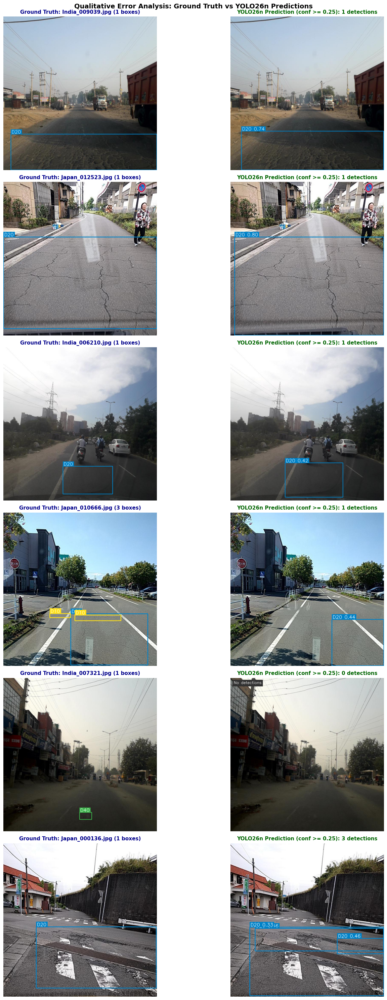

In [22]:
# 6. Qualitative Visual Comparison Visualizer

def draw_predictions_rgb(image_rgb: np.ndarray, boxes_xyxy: np.ndarray, classes: np.ndarray, confs: np.ndarray) -> np.ndarray:
    img = image_rgb.copy()
    h, w, _ = img.shape
    min_dim = float(min(w, h))

    if len(boxes_xyxy) == 0:
        label_text = "No detections"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = max(0.5, min_dim / 1200.0)
        thickness = max(1, int(min_dim / 600.0))
        (tw, th), bl = cv2.getTextSize(label_text, font, font_scale, thickness)
        cv2.rectangle(img, (10, 10), (20 + tw, 20 + th + bl), (50, 50, 50), -1)
        cv2.putText(img, label_text, (15, 15 + th), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)
        return img

    for (xmin, ymin, xmax, ymax), cls_id, conf in zip(boxes_xyxy, classes, confs):
        cls_name = CLASS_NAMES.get(int(cls_id), f"Class {cls_id}")
        color = CLASS_COLORS_RGB.get(int(cls_id), (0, 255, 0))
        label_str = f"{cls_name} {conf:.2f}"

        xmin = max(0, min(w - 1, int(xmin)))
        ymin = max(0, min(h - 1, int(ymin)))
        xmax = max(0, min(w - 1, int(xmax)))
        ymax = max(0, min(h - 1, int(ymax)))

        box_thickness = max(2, int(min_dim / 350.0))
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, box_thickness)

        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = max(0.5, min_dim / 1000.0)
        text_thickness = max(1, int(min_dim / 500.0))
        (tw, th), bl = cv2.getTextSize(label_str, font, font_scale, text_thickness)

        tag_ymin = max(0, ymin - th - 6)
        tag_ymax = ymin
        tag_xmax = min(w, xmin + tw + 6)

        cv2.rectangle(img, (xmin, tag_ymin), (tag_xmax, tag_ymax), color, -1)
        cv2.putText(img, label_str, (xmin + 3, tag_ymax - 3), font, font_scale, (255, 255, 255), text_thickness, cv2.LINE_AA)

    return img


def run_qualitative_evaluation(model_obj, yaml_path: Path, num_samples: int = 6, conf_threshold: float = 0.25, seed: int = 42):

    with open(yaml_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    base = Path(cfg.get("path", yaml_path.parent))
    val_dir = Path(cfg["val"]) if Path(cfg["val"]).is_absolute() else base / cfg["val"]
    val_lbl_dir = val_dir.parent / "labels" if val_dir.parent.name != "images" else val_dir.parent.parent / "labels"
    if not val_lbl_dir.exists():
        val_lbl_dir = val_dir.parent / "val" / "labels"

    val_imgs = sorted(list(val_dir.glob("*.jpg")) + list(val_dir.glob("*.png")))
    if not val_imgs:
        print("No validation images found for visual comparison.")
        return

    # Select samples with annotations for meaningful comparison
    rng = random.Random(seed)
    shuffled_imgs = list(val_imgs)
    rng.shuffle(shuffled_imgs)

    selected = []
    for img_p in shuffled_imgs:
        lbl_p = val_lbl_dir / f"{img_p.stem}.txt"
        ann = read_yolo_labels(lbl_p)
        if len(ann) > 0:
            selected.append((img_p, ann))
        if len(selected) >= num_samples:
            break

    if not selected:
        selected = [(p, []) for p in shuffled_imgs[:num_samples]]

    fig, axes = plt.subplots(len(selected), 2, figsize=(16, 5 * len(selected)))
    if len(selected) == 1:
        axes = np.expand_dims(axes, 0)

    for idx, (img_p, gt_ann) in enumerate(selected):
        bgr = cv2.imread(str(img_p))
        if bgr is None:
            continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        # 1. Ground Truth Visual
        gt_vis = draw_yolo_annotations_rgb(rgb, gt_ann)
        axes[idx, 0].imshow(gt_vis)
        axes[idx, 0].set_title(f"Ground Truth: {img_p.name} ({len(gt_ann)} boxes)", fontsize=11, fontweight="bold", color="darkblue")
        axes[idx, 0].axis("off")

        # 2. YOLO26n Prediction Visual
        preds = model_obj.predict(str(img_p), conf=conf_threshold, verbose=False)[0]
        if preds.boxes is not None and len(preds.boxes) > 0:
            boxes_xyxy = preds.boxes.xyxy.cpu().numpy()
            classes = preds.boxes.cls.cpu().numpy()
            confs = preds.boxes.conf.cpu().numpy()
        else:
            boxes_xyxy, classes, confs = np.array([]), np.array([]), np.array([])

        pred_vis = draw_predictions_rgb(rgb, boxes_xyxy, classes, confs)
        axes[idx, 1].imshow(pred_vis)
        axes[idx, 1].set_title(f"YOLO26n Prediction (conf >= {conf_threshold}): {len(boxes_xyxy)} detections", fontsize=11, fontweight="bold", color="darkgreen")
        axes[idx, 1].axis("off")

    plt.suptitle("Qualitative Error Analysis: Ground Truth vs YOLO26n Predictions", fontsize=14, fontweight="bold", y=0.99)
    plt.tight_layout()
    plt.savefig(WORKSPACE_DIR / "qualitative_val_predictions.png", dpi=150)
    plt.show()


run_qualitative_evaluation(eval_model, DATA_YAML_PATH, num_samples=6, conf_threshold=0.25, seed=42)


## 7. Final Experiment Summary Report
Below is the consolidated performance summary report for the YOLO26n model on the RDD2020 validation set.

In [23]:
# 7. Concise Experiment Summary Report

summary_output = f"""
Model: YOLO26n
Image size: 768
Epochs: 50
Best checkpoint: {best_checkpoint_path}

mAP@50: {overall_map50:.4f}
mAP@50–95: {overall_map5095:.4f}
Precision: {overall_mp:.4f}
Recall: {overall_mr:.4f}

Per-class:
D00: mAP@50={per_class_results['D00']['mAP50']:.4f}, mAP@50-95={per_class_results['D00']['mAP50-95']:.4f}, Precision={per_class_results['D00']['Precision']:.4f}, Recall={per_class_results['D00']['Recall']:.4f}
D10: mAP@50={per_class_results['D10']['mAP50']:.4f}, mAP@50-95={per_class_results['D10']['mAP50-95']:.4f}, Precision={per_class_results['D10']['Precision']:.4f}, Recall={per_class_results['D10']['Recall']:.4f}
D20: mAP@50={per_class_results['D20']['mAP50']:.4f}, mAP@50-95={per_class_results['D20']['mAP50-95']:.4f}, Precision={per_class_results['D20']['Precision']:.4f}, Recall={per_class_results['D20']['Recall']:.4f}
D40: mAP@50={per_class_results['D40']['mAP50']:.4f}, mAP@50-95={per_class_results['D40']['mAP50-95']:.4f}, Precision={per_class_results['D40']['Precision']:.4f}, Recall={per_class_results['D40']['Recall']:.4f}
"""

print(summary_output.strip())

# Save summary report to file
summary_file = WORKSPACE_DIR / "experiment_summary.txt"
with open(summary_file, "w", encoding="utf-8") as f:
    f.write(summary_output.strip() + "\n")


Model: YOLO26n
Image size: 768
Epochs: 50
Best checkpoint: /kaggle/working/outputs/training/yolo26n_rdd2020_768/weights/best.pt

mAP@50: 0.5251
mAP@50–95: 0.2387
Precision: 0.5751
Recall: 0.4999

Per-class:
D00: mAP@50=0.4478, mAP@50-95=0.1996, Precision=0.5465, Recall=0.4108
D10: mAP@50=0.4424, mAP@50-95=0.1770, Precision=0.5362, Recall=0.4246
D20: mAP@50=0.7030, mAP@50-95=0.3632, Precision=0.6521, Recall=0.6722
D40: mAP@50=0.5072, mAP@50-95=0.2148, Precision=0.5655, Recall=0.4920


In [24]:
from pathlib import Path
import shutil

src = Path("/kaggle/working/outputs/training/yolo26n_rdd2020_768/weights")

shutil.copy2(
    src / "best.pt",
    "/kaggle/working/yolo26n_rdd2020_768_best.pt"
)

shutil.copy2(
    src / "last.pt",
    "/kaggle/working/yolo26n_rdd2020_768_last.pt"
)

print("Saved:")
print("/kaggle/working/yolo26n_rdd2020_768_best.pt")
print("/kaggle/working/yolo26n_rdd2020_768_last.pt")

Saved:
/kaggle/working/yolo26n_rdd2020_768_best.pt
/kaggle/working/yolo26n_rdd2020_768_last.pt


## 8 In-Depth Error Analysis (False Positives & False Negatives)
To understand failure modes, we systematically evaluate detection errors:
* **False Positives (FP)**: Model detects damage where none exists or with the wrong class.
* **False Negatives (FN)**: Model misses actual road damage present in the ground truth.

Visualizing these cases provides actionable insights into edge cases such as faint surface cracks, shadow artifacts, or complex multi-class intersections.


YOLO26n 768 — ERROR ANALYSIS
Images analyzed : 4207
Error cases     : 12
Confidence      : 0.25
IoU threshold   : 0.5

False Positives:
  D00 : 1
  D10 : 1
  D20 : 4
  D40 : 1

False Negatives:
  D00 : 3
  D10 : 5
  D20 : 2
  D40 : 9


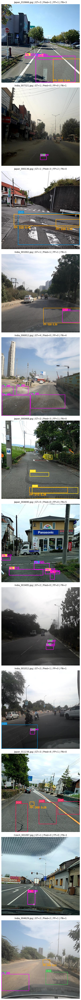


Saved error analysis to:
/kaggle/working/yolo26n_768_error_analysis.png


In [26]:
# 8. Error Analysis — False Positives & False Negatives

from collections import defaultdict


def analyze_detection_errors(
    model_obj,
    yaml_path: Path,
    num_samples: int = 12,
    conf_threshold: float = 0.25,
    iou_threshold: float = 0.5,
    seed: int = 42,
):

    with open(yaml_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    base = Path(cfg.get("path", yaml_path.parent))

    val_dir = (
        Path(cfg["val"])
        if Path(cfg["val"]).is_absolute()
        else base / cfg["val"]
    )

    val_lbl_dir = val_dir.parent / "labels"

    val_imgs = sorted(
        list(val_dir.glob("*.jpg")) +
        list(val_dir.glob("*.png"))
    )

    rng = random.Random(seed)
    rng.shuffle(val_imgs)

    error_cases = []

    def xywhn_to_xyxy(box, width, height):
        cls, xc, yc, bw, bh = box

        return np.array([
            (xc - bw / 2) * width,
            (yc - bh / 2) * height,
            (xc + bw / 2) * width,
            (yc + bh / 2) * height
        ])

    def calculate_iou(box1, box2):
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])

        intersection = max(0, x2 - x1) * max(0, y2 - y1)

        area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
        area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

        union = area1 + area2 - intersection

        if union <= 0:
            return 0.0

        return intersection / union

    for img_path in val_imgs:

        label_path = val_lbl_dir / f"{img_path.stem}.txt"

        image = cv2.imread(str(img_path))

        if image is None:
            continue

        height, width = image.shape[:2]

        gt_annotations = read_yolo_labels(label_path)

        gt_boxes = []

        for ann in gt_annotations:
            gt_boxes.append({
                "class": int(ann[0]),
                "box": xywhn_to_xyxy(ann, width, height),
                "matched": False
            })

        result = model_obj.predict(
            str(img_path),
            conf=conf_threshold,
            verbose=False
        )[0]

        predictions = []

        if result.boxes is not None and len(result.boxes) > 0:

            boxes = result.boxes.xyxy.cpu().numpy()
            classes = result.boxes.cls.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()

            for box, cls, conf in zip(boxes, classes, confs):
                predictions.append({
                    "class": int(cls),
                    "box": box,
                    "conf": float(conf),
                    "matched": False
                })
        # Match predictions to Ground Truth

        for pred in predictions:

            best_iou = 0
            best_gt = None

            for gt in gt_boxes:

                if gt["matched"]:
                    continue

                if gt["class"] != pred["class"]:
                    continue

                iou = calculate_iou(pred["box"], gt["box"])

                if iou > best_iou:
                    best_iou = iou
                    best_gt = gt

            if best_gt is not None and best_iou >= iou_threshold:
                pred["matched"] = True
                best_gt["matched"] = True

        false_positives = [
            p for p in predictions
            if not p["matched"]
        ]

        false_negatives = [
            g for g in gt_boxes
            if not g["matched"]
        ]

        if false_positives or false_negatives:

            error_cases.append({
                "image": img_path,
                "false_positives": false_positives,
                "false_negatives": false_negatives,
                "gt_count": len(gt_boxes),
                "prediction_count": len(predictions)
            })

        if len(error_cases) >= num_samples:
            break


    print("\n" + "=" * 70)
    print("YOLO26n 768 — ERROR ANALYSIS")
    print("=" * 70)

    print(f"Images analyzed : {len(val_imgs)}")
    print(f"Error cases     : {len(error_cases)}")
    print(f"Confidence      : {conf_threshold}")
    print(f"IoU threshold   : {iou_threshold}")

    fp_by_class = defaultdict(int)
    fn_by_class = defaultdict(int)

    for case in error_cases:

        for fp in case["false_positives"]:
            fp_by_class[fp["class"]] += 1

        for fn in case["false_negatives"]:
            fn_by_class[fn["class"]] += 1

    print("\nFalse Positives:")
    for cls_id, count in sorted(fp_by_class.items()):
        print(f"  {CLASS_NAMES.get(cls_id, cls_id)} : {count}")

    print("\nFalse Negatives:")
    for cls_id, count in sorted(fn_by_class.items()):
        print(f"  {CLASS_NAMES.get(cls_id, cls_id)} : {count}")

    # --------------------------------------------------------------------------
    # Visualize error cases
    # --------------------------------------------------------------------------

    if not error_cases:
        print("\nNo error cases found.")
        return

    n = len(error_cases)

    fig, axes = plt.subplots(
        n,
        1,
        figsize=(14, 6 * n)
    )

    if n == 1:
        axes = [axes]

    for ax, case in zip(axes, error_cases):

        img = cv2.imread(str(case["image"]))

        if img is None:
            continue

        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Ground Truth
        gt_ann = read_yolo_labels(
            val_lbl_dir / f"{case['image'].stem}.txt"
        )

        vis = draw_yolo_annotations_rgb(rgb, gt_ann)

        # Draw false negatives
        h, w = rgb.shape[:2]

        for fn in case["false_negatives"]:

            x1, y1, x2, y2 = map(int, fn["box"])

            cv2.rectangle(
                vis,
                (x1, y1),
                (x2, y2),
                (255, 0, 255),
                max(2, int(min(w, h) / 350))
            )

            cv2.putText(
                vis,
                f"FN: {CLASS_NAMES.get(fn['class'], fn['class'])}",
                (x1, max(20, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 255),
                2
            )

        # Draw false positives
        for fp in case["false_positives"]:

            x1, y1, x2, y2 = map(int, fp["box"])

            cv2.rectangle(
                vis,
                (x1, y1),
                (x2, y2),
                (255, 165, 0),
                max(2, int(min(w, h) / 350))
            )

            cv2.putText(
                vis,
                f"FP: {CLASS_NAMES.get(fp['class'], fp['class'])} {fp['conf']:.2f}",
                (x1, min(h - 10, y2 + 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 165, 0),
                2
            )

        ax.imshow(vis)
        ax.set_title(
            f"{case['image'].name} | "
            f"GT={case['gt_count']} | "
            f"Pred={case['prediction_count']} | "
            f"FP={len(case['false_positives'])} | "
            f"FN={len(case['false_negatives'])}",
            fontsize=11
        )
        ax.axis("off")

    plt.tight_layout()

    output_path = WORKSPACE_DIR / "yolo26n_768_error_analysis.png"

    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print(f"\nSaved error analysis to:")
    print(output_path)


# Run analysis
analyze_detection_errors(
    eval_model,
    DATA_YAML_PATH,
    num_samples=12,
    conf_threshold=0.25,
    iou_threshold=0.5,
    seed=42
)

## 9. Comparative Model Benchmark: YOLO11n vs. YOLO26n
In this final section, we load both the baseline **YOLO11n (640px)** and the enhanced **YOLO26n (768px)** checkpoints to compare multi-model predictions across a set of diverse road damage validation scenarios.

In [27]:
# 9. Road Damage Detection Prototype

from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

BEST_MODEL = Path(
    "/kaggle/working/yolo26n_rdd2020_768_best.pt"
)

assert BEST_MODEL.exists(), f"Model not found: {BEST_MODEL}"

prototype_model = YOLO(str(BEST_MODEL))

print("✓ Loaded final model:")
print(BEST_MODEL)

✓ Loaded final model:
/kaggle/working/yolo26n_rdd2020_768_best.pt


Selected test image:
/kaggle/working/data/yolo/val/images/Czech_000006.jpg


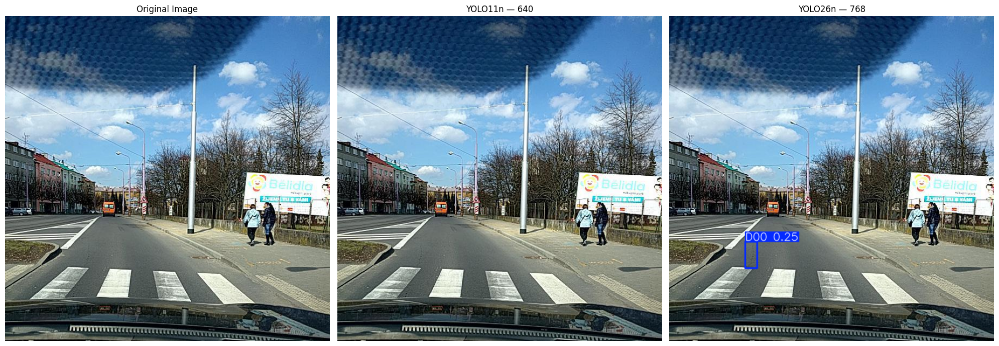


YOLO11n — Baseline
--------------------------------------------------
No detections.

YOLO26n — Final 768
--------------------------------------------------
D00 | confidence = 0.253


In [31]:
# 9. Prototype — Test on an Annotated Validation Image

from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import yaml

# --------------------------------------------------------------------------
# Find validation directories
# --------------------------------------------------------------------------

with open(DATA_YAML_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

base = Path(cfg.get("path", DATA_YAML_PATH.parent))

val_dir = (
    Path(cfg["val"])
    if Path(cfg["val"]).is_absolute()
    else base / cfg["val"]
)

val_label_dir = val_dir.parent / "labels"

# --------------------------------------------------------------------------
# Find an image that actually has annotations
# --------------------------------------------------------------------------

candidate_images = sorted(
    list(val_dir.glob("*.jpg")) +
    list(val_dir.glob("*.png"))
)

test_image = None

for image_path in candidate_images:
    label_path = val_label_dir / f"{image_path.stem}.txt"

    if label_path.exists() and label_path.stat().st_size > 0:
        test_image = image_path
        break

assert test_image is not None, "No annotated validation image found."

print(f"Selected test image:")
print(test_image)

YOLO26_MODEL = Path(
    "/kaggle/working/yolo26n_rdd2020_768_best.pt"
)

YOLO11_MODEL = Path(
    "/kaggle/working/rdd2020_yolo_best.pt"
)

assert YOLO26_MODEL.exists(), f"YOLO26n checkpoint not found: {YOLO26_MODEL}"
assert YOLO11_MODEL.exists(), f"YOLO11n checkpoint not found: {YOLO11_MODEL}"

model_26 = YOLO(str(YOLO26_MODEL))
model_11 = YOLO(str(YOLO11_MODEL))


result_26 = model_26.predict(
    source=str(test_image),
    imgsz=768,
    conf=0.25,
    verbose=False
)[0]

result_11 = model_11.predict(
    source=str(test_image),
    imgsz=640,
    conf=0.25,
    verbose=False
)[0]

img = cv2.imread(str(test_image))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pred_26 = cv2.cvtColor(
    result_26.plot(),
    cv2.COLOR_BGR2RGB
)

pred_11 = cv2.cvtColor(
    result_11.plot(),
    cv2.COLOR_BGR2RGB
)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(pred_11)
axes[1].set_title("YOLO11n — 640")
axes[1].axis("off")

axes[2].imshow(pred_26)
axes[2].set_title("YOLO26n — 768")
axes[2].axis("off")

plt.tight_layout()
plt.show()
def print_detections(result, model_name):

    print(f"\n{model_name}")
    print("-" * 50)

    if result.boxes is None or len(result.boxes) == 0:
        print("No detections.")
        return

    for box in result.boxes:
        cls_id = int(box.cls.item())
        confidence = float(box.conf.item())

        class_name = CLASS_NAMES.get(
            cls_id,
            f"Class {cls_id}"
        )

        print(
            f"{class_name} | confidence = {confidence:.3f}"
        )


print_detections(result_11, "YOLO11n — Baseline")
print_detections(result_26, "YOLO26n — Final 768")

In [30]:
print("\nDetected road damages:")
print("-" * 50)

if result.boxes is None or len(result.boxes) == 0:
    print("No damage detected.")
else:
    for box in result.boxes:
        cls_id = int(box.cls.item())
        confidence = float(box.conf.item())

        class_name = CLASS_NAMES.get(
            cls_id,
            f"Class {cls_id}"
        )

        print(
            f"{class_name:>4} | "
            f"confidence = {confidence:.3f}"
        )


Detected road damages:
--------------------------------------------------
No damage detected.


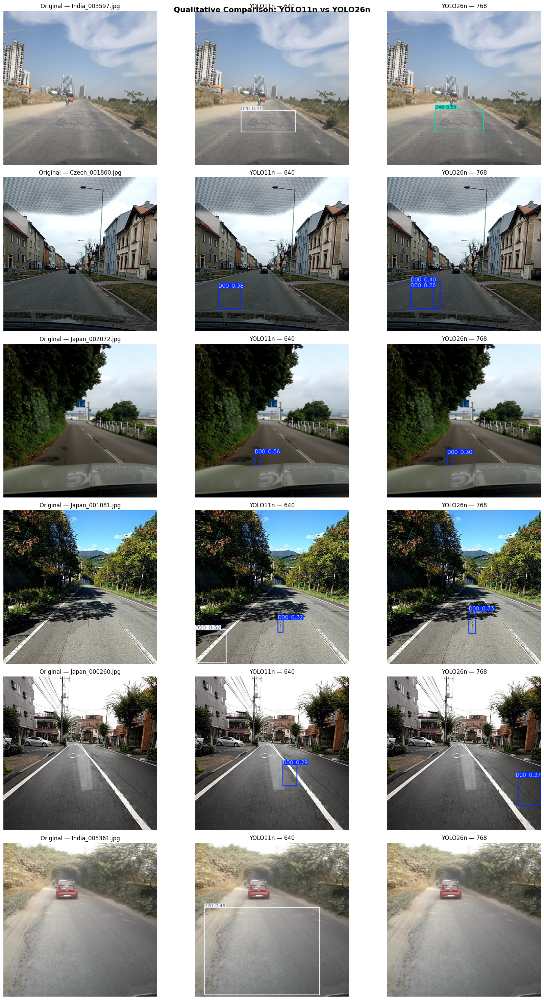

✓ Comparison saved to:
/kaggle/working/yolo11n_vs_yolo26n_6_images.png


In [32]:
# 10. YOLO11n vs YOLO26n — 6 Image Comparison

import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

images = []

for img_path in sorted(
    list(val_dir.glob("*.jpg")) +
    list(val_dir.glob("*.png"))
):
    label_path = val_label_dir / f"{img_path.stem}.txt"

    if label_path.exists() and label_path.stat().st_size > 0:
        images.append(img_path)

random.seed(42)
selected_images = random.sample(images, min(6, len(images)))

fig, axes = plt.subplots(
    len(selected_images),
    3,
    figsize=(18, 5 * len(selected_images))
)

if len(selected_images) == 1:
    axes = [axes]

for i, image_path in enumerate(selected_images):

    # Original
    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # YOLO11n
    result_11 = model_11.predict(
        str(image_path),
        imgsz=640,
        conf=0.25,
        verbose=False
    )[0]

    # YOLO26n 768
    result_26 = model_26.predict(
        str(image_path),
        imgsz=768,
        conf=0.25,
        verbose=False
    )[0]

    pred_11 = cv2.cvtColor(
        result_11.plot(),
        cv2.COLOR_BGR2RGB
    )

    pred_26 = cv2.cvtColor(
        result_26.plot(),
        cv2.COLOR_BGR2RGB
    )

    # Plot
    axes[i][0].imshow(image_rgb)
    axes[i][0].set_title(f"Original — {image_path.name}")
    axes[i][0].axis("off")

    axes[i][1].imshow(pred_11)
    axes[i][1].set_title("YOLO11n — 640")
    axes[i][1].axis("off")

    axes[i][2].imshow(pred_26)
    axes[i][2].set_title("YOLO26n — 768")
    axes[i][2].axis("off")

plt.suptitle(
    "Qualitative Comparison: YOLO11n vs YOLO26n",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

comparison_path = Path(
    "/kaggle/working/yolo11n_vs_yolo26n_6_images.png"
)

plt.savefig(
    comparison_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Comparison saved to:")
print(comparison_path)